# Lookups, scatters and sums

Read a table, scatter into shared bins, and let each sample total its
own contributions — three plane kinds every earlier tutorial skipped.

**Time:** ~8 min · **Runs on:** CPU · **You need:**
[Stop when you're done](03_stop_when_youre_done)

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / "_shared"))
from nb_helpers import plot_style
plot_style()


## Table: a per-sample lookup

`Table[...]` is a per-sample lookup, read with `.at(index)` through an
`Index` plane. Every sample here reads a DIFFERENT table entry, by its
own index:

In [2]:
import numpy as np

import hawk
from hawk import Index, Mutable, Scalar, Table


@hawk.kernel
def gather(table: Table[Scalar], where: Index, y: Mutable[Scalar]):
    y = table.at(where)


gather


<Kernel gather slots=3>

`hawk.artifact.build` + `hawk.load`/`hawk.run` build and run it on the host:


In [3]:
import pathlib, tempfile

import hawk.artifact

work_dir = pathlib.Path(tempfile.mkdtemp())
n = 8
table_vals = np.arange(n, dtype=float) * 3.0
where = ((np.arange(n) * 7 + 3) % n).astype(np.int64)   # Index plane: int64, not int32
y = np.zeros(n)
hawk.artifact.build(gather, work_dir, targets=("host",))
hawk.run(hawk.load(work_dir, "gather"), table=table_vals, where=where, y=y)
print("gather:", y)


gather: [ 9.  6.  3.  0. 21. 18. 15. 12.]


`where` is `int64` on purpose: an `Index` plane drives a real memory
address, as the refusal at the end of this page shows.

## Accum: a cross-sample scatter

`Accum[...]` is a cross-sample scatter, written with `.add(value,
at=lane)` — many samples can land in the same bin, like a histogram:

In [4]:
from hawk import Accum

rng = np.random.default_rng(0)


@hawk.kernel
def histogram(lane: Index, acc: Accum[Scalar]):
    acc.add(1.0, at=lane)


histogram


<Kernel histogram slots=2>

Build and run it the same way:


In [5]:
n_samples, n_bins = 2000, 10
lane = rng.integers(0, n_bins, size=n_samples).astype(np.int64)
acc = np.zeros(n_bins)
hawk.artifact.build(histogram, work_dir, targets=("host",))
hawk.run(hawk.load(work_dir, "histogram"), lane=lane, acc=acc)
expect = np.bincount(lane, minlength=n_bins).astype(float)
print("Accum matches np.bincount:", np.allclose(acc, expect))


Accum matches np.bincount: True


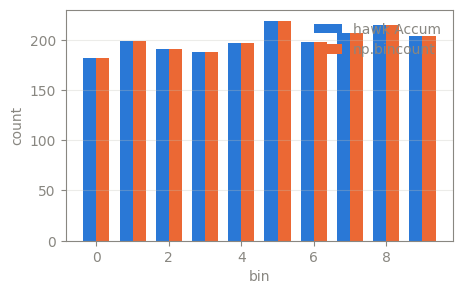

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 3))
bins = np.arange(n_bins)
ax.bar(bins - 0.18, acc, width=0.36, color="#2a78d6", label="hawk Accum")
ax.bar(bins + 0.18, expect, width=0.36, color="#eb6834", label="np.bincount")
ax.set_xlabel("bin"); ax.set_ylabel("count"); ax.legend(frameon=False)
ax.grid(alpha=0.3, axis="y")
plt.show()

## Reduce: one slot per sample, not one running total

`Reduce("sum")` takes **parentheses**, not brackets like `Table[...]`:
its argument is the combine op's name, resolved when hawk traces the
kernel (turns it into IR, before it ever runs), not a type.
`.contribute(value)` writes into a **mapreduce slot** — one accumulator
per sample that every `.contribute` call in the body adds into, the same
idea a true map-reduce combines partial results with, just scoped to one
sample instead of a whole cluster:

In [7]:
from hawk import Reduce, Vector
from hawk.math import dot


@hawk.kernel
def energy(v: Vector[3], total: Reduce("sum")):
    total.contribute(dot(v, v))


energy


<Kernel energy slots=2>

Build and run it:


In [8]:
n = 8
v = rng.normal(size=(3, n))
total = np.zeros(n)
hawk.artifact.build(energy, work_dir, targets=("host",))
hawk.run(hawk.load(work_dir, "energy"), v=v, total=total)
print("energy, one slot per sample:", total)


energy, one slot per sample: [1.37902901 2.90811709 8.98823442 0.99007907 4.01012216 7.65868338
 3.10053932 1.59897325]


## A value carried across several launches

The same bound `best` array, the same kernel, called once per step: each
launch reads the value the *previous* launch committed, simply by
reading `best` before writing it — the same convention
[Stop when you're done](03_stop_when_youre_done) used to step a
trajectory:

In [9]:
from hawk import Terminated
from hawk.math import maximum


@hawk.kernel
def running_max(value: Scalar, terminated: Terminated, best: Mutable[Scalar]):
    best = maximum(best, value)


running_max


<Kernel running_max slots=3>

Build it once, then call it five times, reading `best` back each time:


In [10]:
hawk.artifact.build(running_max, work_dir, targets=("host",))
running_max_k = hawk.load(work_dir, "running_max")
best = np.zeros(n)
terminated = np.zeros(n, dtype=bool)
for value in (3.0, 7.0, 2.0, 9.0, 4.0):
    hawk.run(running_max_k, value=np.full(n, value), terminated=terminated, best=best)
print("running max after 5 launches (expect 9.0 everywhere):", best)


running max after 5 launches (expect 9.0 everywhere): [9. 9. 9. 9. 9. 9. 9. 9.]


## A wrong binding, refused by name

`hawk.run` checks every bound argument against the kernel's own
declaration before taking its address — the SAME `gather` kernel from
above, with `where` bound as `int32` instead of `int64`:

In [11]:
from hawk.ir import HawkError

gather_host = hawk.load(work_dir, "gather")
try:
    hawk.run(gather_host, table=table_vals, where=where.astype(np.int32), y=y)
except HawkError as exc:
    print("refused:", exc)


refused: kernel 'gather': argument 'where': expected dtype int64, got int32 — pass np.asarray(where, dtype=np.int64)


## What just happened

- `Table[...].at(index)` is a per-sample lookup; `Accum[...].add(value,
  at=lane)` scatters across samples into shared bins; `Reduce("sum")`
  gives each sample its own mapreduce slot — three different ways data
  crosses between samples, none of them a hidden Python loop.
- `Index` planes (`where`, `lane`) are always `int64`; a wrong dtype is
  refused by name rather than silently misread.
- Reading a `Mutable` before writing it carries a value from one launch
  to the next — the same mechanism [Stop when you're done](03_stop_when_youre_done)
  used to step a trajectory, here running a max across five launches.

## Try this

Change `Reduce("sum")` to add a second contribution (say `total.contribute(1.0)`
in a second statement) and check that `total` becomes `energy + 1` for
every sample — a mapreduce slot accumulates everything a launch
contributes to it.

## Next

[Writing a vocabulary](../vocabulary/01_a_family_of_kernels) — declare a reusable
kernel *shape* once, so a whole family of models shares one vocabulary.
*Deeper:* the [API reference](../api/index) for every plane kind and sink
policy.